# Deteccion del ciclo de las manchas solares

Notebook de ajuste, diagnostico y prediccion para la serie mensual de manchas solares de SILSO.

In [33]:
# Si el paquete local no esta instalado en el kernel, descomenta esta linea.
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [34]:
from pathlib import Path
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from cyclical_fractional_test import (
    CyclicalFractionalModel,
    CyclicalTestConfig,
    compute_autocorrelogram,
    compute_periodogram,
)
from cyclical_fractional_test.regression import DEFAULT_BETA_SIGNIFICANCE_CRITICAL_VALUE

logging.basicConfig(level=logging.WARNING, format="%(levelname)s:%(name)s:%(message)s", force=True)

DATA_DIR = REPO_ROOT / "data"
FIG_DIR = REPO_ROOT / "figures" / "sunspots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Datos mensuales SILSO

In [35]:
SUNSPOT_FILE = DATA_DIR / "MONTHLY.csv"
TARGET_TOTAL_OBS = 3330
TEXT_TRAIN_SIZE = 2997

sunspots_raw = pd.read_csv(SUNSPOT_FILE, sep=";")
sunspots_raw.columns = sunspots_raw.columns.str.strip()

sunspots_raw["year"] = pd.to_numeric(sunspots_raw["year"], errors="coerce").astype("Int64")
sunspots_raw["month"] = pd.to_numeric(sunspots_raw["month"], errors="coerce").astype("Int64")
sunspots_raw["sunspot_mean"] = pd.to_numeric(sunspots_raw["sunspot_mean"], errors="coerce")
sunspots_raw["date"] = pd.to_datetime(
    {
        "year": sunspots_raw["year"].astype(int),
        "month": sunspots_raw["month"].astype(int),
        "day": 1,
    }
)

sunspots_raw = (
    sunspots_raw
    .dropna(subset=["date", "sunspot_mean"])
    .sort_values("date")
    .reset_index(drop=True)
)

if TARGET_TOTAL_OBS is not None and len(sunspots_raw) >= TARGET_TOTAL_OBS:
    sunspots = sunspots_raw.iloc[:TARGET_TOTAL_OBS].copy()
else:
    sunspots = sunspots_raw.copy()
    print(
        f"Aviso: el CSV contiene {len(sunspots_raw)} observaciones; "
        f"se usa toda la muestra disponible en lugar de {TARGET_TOTAL_OBS}."
    )

y = sunspots["sunspot_mean"].to_numpy(dtype=float)
dates = sunspots["date"].reset_index(drop=True)
T = len(y)
T_train = TEXT_TRAIN_SIZE if T > TEXT_TRAIN_SIZE else int(0.9 * T)
y_train = y[:T_train]
y_test = y[T_train:]

print(f"T total: {T}")
print(f"T train: {T_train}")
print(f"T test: {len(y_test)}")
print(f"Periodo cubierto: {dates.iloc[0].date()} - {dates.iloc[-1].date()}")
display(sunspots.head())

Aviso: el CSV contiene 3329 observaciones; se usa toda la muestra disponible en lugar de 3330.
T total: 3329
T train: 2997
T test: 332
Periodo cubierto: 1749-01-01 - 2026-05-01


,year,month,date_fraction,sunspot_mean,sunspot_std,n_observations,definitive,date
0,1749,1,1749.042,96.7,-1.0,-1,1,1749-01-01
1,1749,2,1749.123,104.3,-1.0,-1,1,1749-02-01
2,1749,3,1749.204,116.7,-1.0,-1,1,1749-03-01
3,1749,4,1749.288,92.8,-1.0,-1,1,1749-04-01
4,1749,5,1749.371,141.7,-1.0,-1,1,1749-05-01


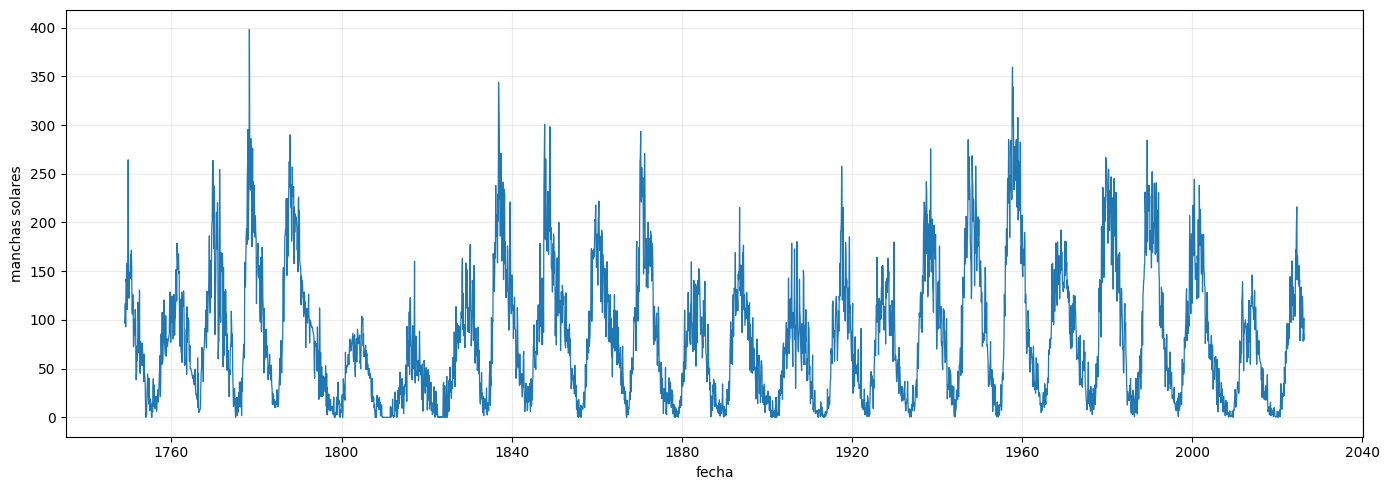

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, y, linewidth=0.9)
ax.set_xlabel("fecha")
ax.set_ylabel("manchas solares")
fig.tight_layout()
fig.savefig(FIG_DIR / "mensual-sunspot-plot.png", dpi=200, bbox_inches="tight")
plt.show()

## Analisis preliminar: periodograma y autocorrelograma

In [37]:
def periodogram_table(values):
    lambdas, intensities = compute_periodogram(values)
    half = len(intensities) // 2
    R = np.arange(half)
    periods = np.full(half, np.inf, dtype=float)
    periods[1:] = len(values) / R[1:]
    return pd.DataFrame({"R": R, "lambda": lambdas[:half], "I": intensities[:half], "period_months": periods})

periodogram_full = periodogram_table(y)
periodogram_train = periodogram_table(y_train)

print("Picos principales en la muestra completa:")
display(periodogram_full.sort_values("I", ascending=False).head(5))

main_nonzero_peak = periodogram_full.loc[periodogram_full["R"] > 0].sort_values("I", ascending=False).iloc[0]
print(
    f"Pico no nulo principal: R={int(main_nonzero_peak.R)}, "
    f"periodo aproximado={main_nonzero_peak.period_months:.2f} meses "
    f"({main_nonzero_peak.period_months / 12:.2f} anos)."
)

print("Picos principales en la muestra de entrenamiento:")
display(periodogram_train.sort_values("I", ascending=False).head(5))

Picos principales en la muestra completa:


,R,lambda,I,period_months
0,0,0.000000,3.580026e+06,inf
25,25,0.047185,2.612841e+05,133.160000
26,26,0.049073,1.648960e+05,128.038462
28,28,0.052847,9.723364e+04,118.892857
3,3,0.005662,7.800066e+04,1109.666667


Pico no nulo principal: R=25, periodo aproximado=133.16 meses (11.10 anos).
Picos principales en la muestra de entrenamiento:


,R,lambda,I,period_months
0,0,0.000000,3.301148e+06,inf
23,23,0.048219,1.938963e+05,130.304348
25,25,0.052412,1.784732e+05,119.880000
22,22,0.046123,7.699636e+04,136.227273
21,21,0.044026,7.443147e+04,142.714286


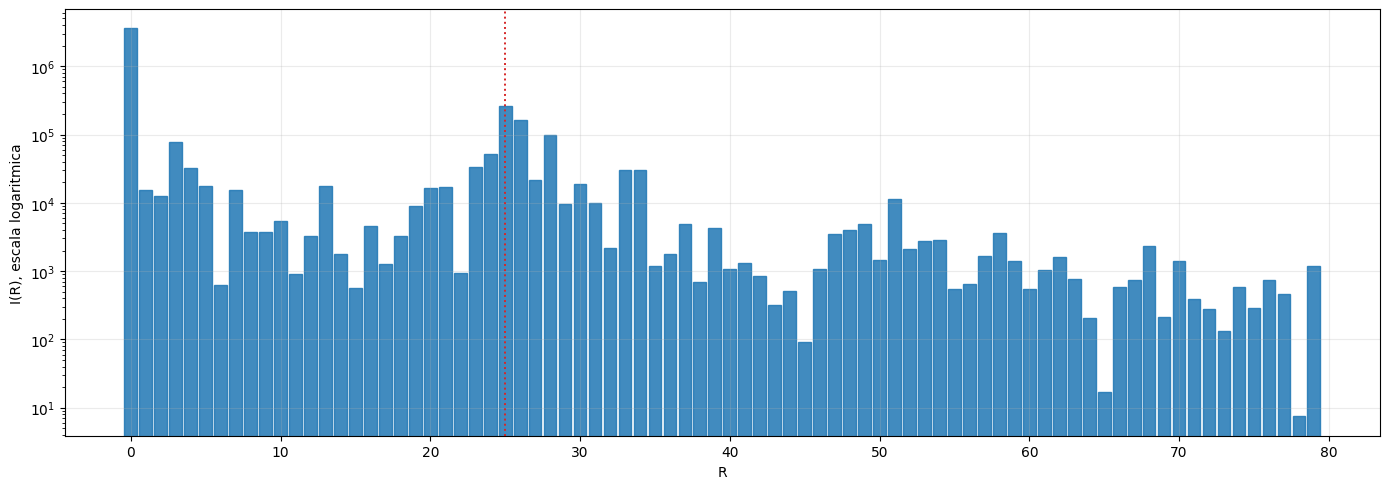

In [38]:
R_MAX_PLOT = 80
plot_df = periodogram_full.iloc[:R_MAX_PLOT]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(plot_df["R"], plot_df["I"], width=0.85, color="tab:blue", edgecolor="tab:blue", alpha=0.85)
ax.set_yscale("log")
# ax.set_title("Periodograma de la serie mensual de manchas solares")
ax.set_xlabel("R")
ax.set_ylabel("I(R), escala logaritmica")
ax.axvline(int(main_nonzero_peak.R), color="tab:red", linestyle=":", linewidth=1.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "sunspot-log-mensual-peridogram.png", dpi=200, bbox_inches="tight")
plt.show()

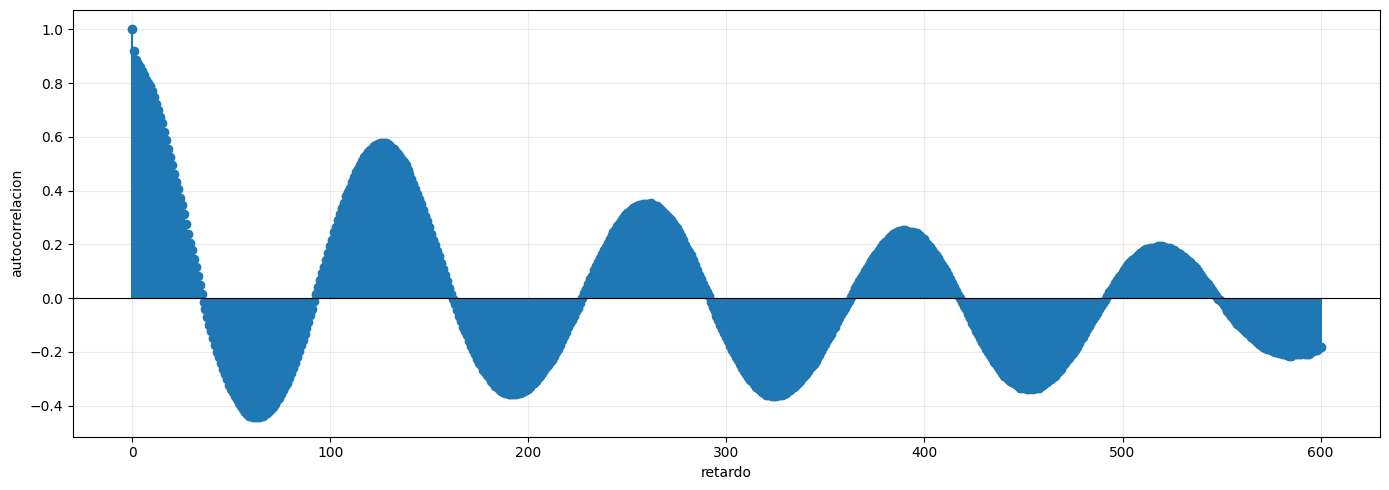

In [39]:
MAX_LAG = 600
lags, autocorr = compute_autocorrelogram(y, max_lag=MAX_LAG)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(lags, autocorr, basefmt=' ')
ax.axhline(0, color="black", linewidth=0.8)
# ax.set_title("Autocorrelograma de la serie mensual de manchas solares")
ax.set_xlabel("retardo")
ax.set_ylabel("autocorrelacion")
fig.tight_layout()
fig.savefig(FIG_DIR / "sunspot-autocorrelogram.png", dpi=200, bbox_inches="tight")
plt.show()

## Funciones auxiliares para los tests y la prediccion

In [40]:
def _cycle_rows(candidate, T_ref):
    rows = []
    for i, cycle in enumerate(candidate.cycles, start=1):
        period = np.inf if cycle.R == 0 else T_ref / cycle.R
        rows.append(
            {
                "cycle": i,
                "R": int(cycle.R),
                "D": float(cycle.D),
                "period_months": period,
                "period_years": period / 12 if np.isfinite(period) else np.inf,
            }
        )
    return rows


def summarize_test_result(model, label, T_ref):
    result = model.result_
    best = result.best_result
    print(label)
    print(f"n_candidates_evaluated: {result.n_candidates_evaluated}")
    print(f"r_peak: {result.r_peak}")
    print(f"r_candidates: {result.r_candidates}")
    print(f"test_value: {best.test_value:.6f}")
    print(f"test_star_value: {best.test_star_value:.6f}")
    print(f"variance_time: {best.variance_time:.6f}")
    print(f"variance_frequency: {best.variance_frequency:.6f}")
    print(f"betas: {np.round(best.betas, 6)}")
    if len(best.ar_coefficients):
        print(f"AR coefficients: {np.round(best.ar_coefficients, 6)}")
    display(pd.DataFrame(_cycle_rows(best, T_ref)))


def top_candidates_table(result, T_ref, n=10):
    rows = []
    for rank, candidate in enumerate(result.top_k_results[:n], start=1):
        row = {
            "rank": rank,
            "test_value": candidate.test_value,
            "abs_test_value": abs(candidate.test_value),
            "test_star_value": candidate.test_star_value,
            "abs_test_star_value": abs(candidate.test_star_value),
            "xa": candidate.xa,
            "xaa": candidate.xaa,
        }
        for i, cycle in enumerate(candidate.cycles, start=1):
            row[f"R_{i}"] = int(cycle.R)
            row[f"D_{i}"] = float(cycle.D)
            row[f"period_{i}"] = np.inf if cycle.R == 0 else T_ref / cycle.R
        rows.append(row)
    return pd.DataFrame(rows)


def beta_names(config):
    names = []
    if config.include_intercept:
        names.append("Intercepto")
    if config.chebyshev_orders is None:
        orders = range(1, config.n_deterministic_cycles + 1)
    else:
        orders = config.chebyshev_orders
    names.extend([f"P_{order}(t)" for order in orders])
    return names


def beta_significance_table(model, critical_value=DEFAULT_BETA_SIGNIFICANCE_CRITICAL_VALUE):
    sig = model.detect_beta_significance(critical_value=critical_value)
    names = beta_names(model.config)
    if len(names) != len(sig.betas):
        names = [f"beta_{i}" for i in range(len(sig.betas))]
    table = pd.DataFrame(
        {
            "coeficiente": names,
            "beta": sig.betas,
            "std_error": sig.standard_errors,
            "t_stat": sig.t_statistics,
            "critical_value": sig.critical_value,
            "significativo": sig.significant,
        }
    )
    return table


def predict_and_score(model, y_values, dates_index, T_train, figure_name, title):
    T_total = len(y_values)
    y_pred = model.predict(T_total)
    lower, upper = model.predict_interval(T_total, alpha=0.05)

    y_test_true = y_values[T_train:T_total]
    y_test_pred = y_pred[T_train:T_total]
    rmse = float(np.sqrt(np.mean((y_test_true - y_test_pred) ** 2)))
    mae = float(np.mean(np.abs(y_test_true - y_test_pred)))

    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates_index, y_values, label="observado", color="black", linewidth=0.9)
    ax.plot(dates_index, y_pred, label="prediccion", color="tab:red", linestyle="--", linewidth=1.0)
    ax.fill_between(dates_index, lower, upper, color="tab:red", alpha=0.12, label="IC 95%")
    ax.axvline(dates_index.iloc[T_train - 1], color="gray", linestyle=":", linewidth=1.2, label="fin del train")
    ax.set_xlim(left=pd.Timestamp("1960-01-01"), right = pd.Timestamp("2027-01-01"))  # mostrar solo desde 1960
    # ax.set_title(title)
    ax.set_xlabel("fecha")
    ax.set_ylabel("manchas solares")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / figure_name, dpi=200, bbox_inches="tight")
    plt.show()

    return {"prediction": y_pred, "lower": lower, "upper": upper, "rmse": rmse, "mae": mae}

## Especificacion general: tres ciclos estocasticos

In [41]:
multi_cycle_config = CyclicalTestConfig(
    n_deterministic_cycles=3,
    include_intercept=True,
    d_search_strategy="fixed_grid",
    d_grid=np.round(np.linspace(0.0, 1.0, 11), 2),
    r_window=1,
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="multi_cycle",
    n_stochastic_cycles=3,
    exclude_zero_frequency=False,
    error_model="white_noise",
)

multi_cycle_model = CyclicalFractionalModel(config=multi_cycle_config)
multi_cycle_model.fit(y_train)

summarize_test_result(multi_cycle_model, "Test con tres ciclos estocasticos", T_train)
display(top_candidates_table(multi_cycle_model.result_, T_train, n=5))

Test con tres ciclos estocasticos
n_candidates_evaluated: 1331
r_peak: 0
r_candidates: [ 0 23 25]
test_value: 0.008053
test_star_value: 0.008110
variance_time: 643.213886
variance_frequency: 638.654906
betas: [83.981872 -4.606533  6.397142 -2.026567]


,cycle,R,D,period_months,period_years
0,1,0,0.0,inf,inf
1,2,23,0.3,130.304348,10.858696
2,3,25,0.0,119.880000,9.990000


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_1,R_2,D_2,period_2,R_3,D_3,period_3
0,1,0.008053,0.008053,0.008110,0.008110,0.699277,54.622366,0,0.0,inf,23,0.3,130.304348,25,0.0,119.88
1,2,-0.088969,0.088969,-0.089969,0.089969,-7.791832,54.622366,0,0.1,inf,23,0.1,130.304348,25,0.1,119.88
2,3,0.348390,0.348390,0.355205,0.355205,31.155977,54.622366,0,0.2,inf,23,0.1,130.304348,25,0.0,119.88
3,4,0.417269,0.417269,0.419991,0.419991,36.275618,54.622366,0,0.0,inf,23,0.2,130.304348,25,0.1,119.88
4,5,-0.705550,0.705550,-0.713907,0.713907,-61.639164,54.622366,0,0.1,inf,23,0.2,130.304348,25,0.0,119.88


In [42]:
# Significatividad de los betas del test con tres ciclos estocasticos.
display(beta_significance_table(multi_cycle_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,Intercepto,83.981872,2.844843,29.520745,1.645,True
1,P_1(t),-4.606533,2.001843,-2.301145,1.645,True
2,P_2(t),6.397142,2.002639,3.194356,1.645,True
3,P_3(t),-2.026567,2.004060,-1.011231,1.645,False


RMSE: 55.108
MAE:  48.345


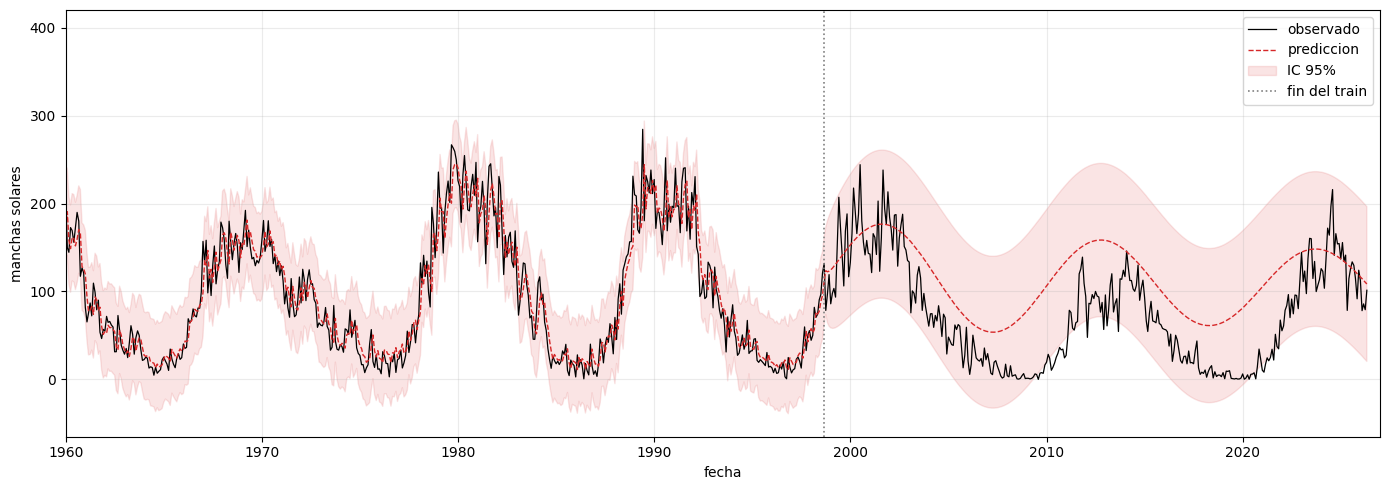

In [43]:
multi_cycle_prediction = predict_and_score(
    multi_cycle_model,
    y,
    dates,
    T_train,
    "pred-sunspot-3-sth-cycles.png",
    "Prediccion con tres ciclos estocasticos",
)

## Especificacion final: un unico ciclo estocastico

In [44]:
single_cycle_config = CyclicalTestConfig(
    n_deterministic_cycles=0,
    include_intercept=True,
    r_window=5,
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="single",
    exclude_zero_frequency=True,
    error_model="white_noise",
)

single_cycle_model = CyclicalFractionalModel(config=single_cycle_config)
single_cycle_model.fit(y_train)

summarize_test_result(single_cycle_model, "Test con un unico ciclo estocastico", T_train)
display(top_candidates_table(single_cycle_model.result_, T_train, n=5))

Test con un unico ciclo estocastico
n_candidates_evaluated: 319
r_peak: 23
r_candidates: [18 19 20 21 22 23 24 25 26 27 28]
test_value: 0.036497
test_star_value: 0.036568
variance_time: 645.588300
variance_frequency: 644.329653
betas: [84.009207]


,cycle,R,D,period_months,period_years
0,1,23,0.31,130.304348,10.858696


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_1
0,1,0.036497,0.036497,0.036568,0.036568,1.066280,6.137744,23,0.31,130.304348
1,2,-0.122866,0.122866,-0.122867,0.122867,-3.679923,6.183637,19,0.33,157.736842
2,3,0.227158,0.227158,0.227264,0.227264,6.717551,6.160795,21,0.32,142.714286
3,4,-0.310777,0.310777,-0.311163,0.311163,-9.139987,6.114534,25,0.32,119.880000
4,5,0.324529,0.324529,0.324531,0.324531,9.767081,6.194961,18,0.33,166.500000


In [45]:
# Significatividad de los betas del test con un unico ciclo estocastico.
display(beta_significance_table(single_cycle_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,Intercepto,84.009207,3.023598,27.784513,1.645,True


RMSE: 39.897
MAE:  33.041


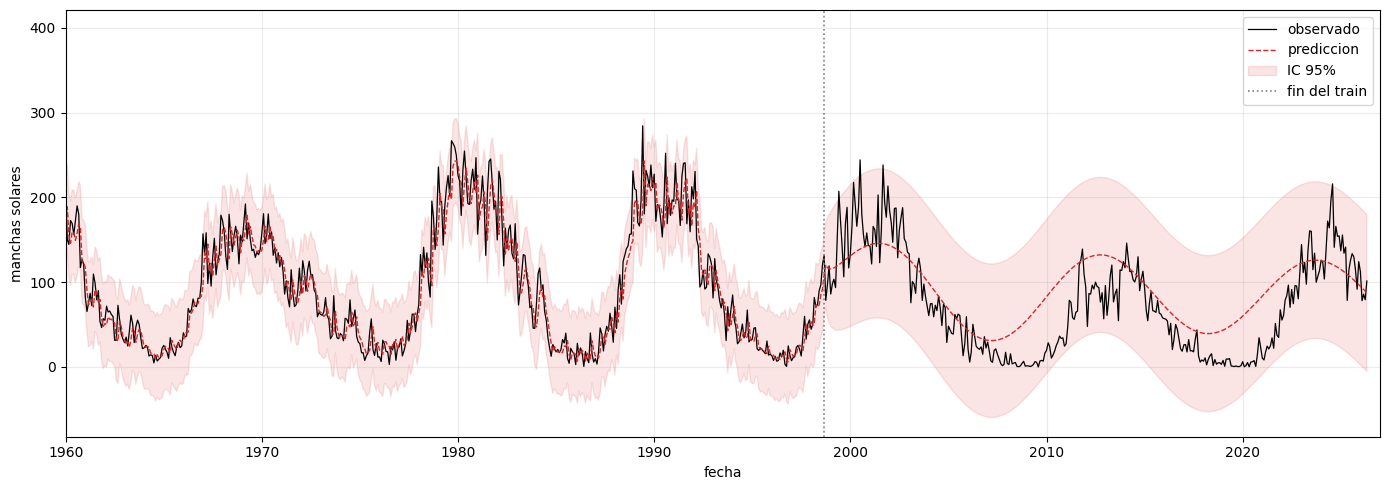

In [46]:
single_cycle_prediction = predict_and_score(
    single_cycle_model,
    y,
    dates,
    T_train,
    "pred-sunspot-unicycle.png",
    "Prediccion con un unico ciclo estocastico",
)

## Comparacion de modelos

In [47]:
comparison = pd.DataFrame(
    [
        {
            "modelo": "tres ciclos estocasticos",
            "RMSE": multi_cycle_prediction["rmse"],
            "MAE": multi_cycle_prediction["mae"],
            "cycles": [(c.R, c.D) for c in multi_cycle_model.cycles_],
            "betas": multi_cycle_model.betas_,
        },
        {
            "modelo": "un ciclo estocastico",
            "RMSE": single_cycle_prediction["rmse"],
            "MAE": single_cycle_prediction["mae"],
            "cycles": [(c.R, c.D) for c in single_cycle_model.cycles_],
            "betas": single_cycle_model.betas_,
        },
    ]
)
display(comparison)

print(f"Figuras guardadas en: {FIG_DIR}")

,modelo,RMSE,MAE,cycles,betas
0,tres ciclos estocasticos,55.108322,48.344610,"[(0, 0.0), (23, 0.3), (25, 0.0)]","[83.98187171819961, -4.606532690636276, 6.3971..."
1,un ciclo estocastico,39.896810,33.041227,"[(23, 0.31)]",[84.00920737776421]


Figuras guardadas en: /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/figures/sunspots
